# 07 — Temporal Validation across the Connectivity Ladder


## 1. Imports & config

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json, os, time
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse import csgraph
from scipy.sparse.csgraph import dijkstra
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, average_precision_score

from common import (ECO_TITLES, MIN_VIEW_POS, N_JOBS, N_LANDMARKS, SEED, make_views,
                    read_csv_literal)

ECO       = os.environ.get("ECO", "npm")
ECO_TITLE = ECO_TITLES[ECO]
MIN_SPLIT_POS = 10          # a rung needs this many positives on each side of the cutoff

ROOT    = Path("..")
PREP    = ROOT / "data" / "output" / ECO / "01_data_prep"
DATA_DIR = ROOT / "data" / "input" / ECO
OUT_DIR = ROOT / "data" / "output" / ECO / "07_temporal_validation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUNGS = ["A: full corpus", "B: has dependents", "C: fully connected"]
RUNG_COLOR = {"A: full corpus": "#85847c", "B: has dependents": "#2a78d6",
              "C: fully connected": "#008300"}
FAM_COLOR = {"Metadata": "#e87ba4", "Graph-11": "#5a5952", "Metadata+Graph": "#eda100"}

t_nb = time.time()
print(f"{ECO_TITLE} | out: {OUT_DIR.resolve()}")


npm | out: C:\Users\amehs\Documents\ThesisAppendixVersion\data\output\npm\07_temporal_validation


## 2. Corpus, edges and risk timestamps

In [2]:
schema = json.loads((PREP / "schema.json").read_text(encoding="utf-8"))
df = read_csv_literal(PREP / "model_ready_dataset.csv")
gf = read_csv_literal(PREP / "graph_features.csv")
edges = read_csv_literal(PREP / "edges.csv")
GRAPH_FEATURES = schema["graph_features"]
META_FEATURES  = schema["meta_features"]
assert len(GRAPH_FEATURES) == 11 and (df["package"] == gf["package"]).all()

N = len(df)
label_arr = df["label"].astype(int).to_numpy()
m_vuln, m_comp = (label_arr == -1), (label_arr == 1)
X_meta = df[META_FEATURES].apply(pd.to_numeric, errors="coerce").values.astype(np.float32)

pos_of = {p: i for i, p in enumerate(df["package"])}
src_all = edges["source"].map(pos_of).to_numpy(dtype=np.int64)
tgt_all = edges["target"].map(pos_of).to_numpy(dtype=np.int64)


def first_ts(fname, key, tcol):
    p = DATA_DIR / fname
    if not p.exists() or p.stat().st_size == 0:
        return pd.Series(dtype="datetime64[ns]")
    d = read_csv_literal(p)
    if key not in d.columns or tcol not in d.columns:
        return pd.Series(dtype="datetime64[ns]")
    d[tcol] = pd.to_datetime(d[tcol], errors="coerce", utc=True).dt.tz_localize(None)
    return d.dropna(subset=[tcol]).groupby(key)[tcol].min()


comp_ts = first_ts("malicious_all.csv", "package", "attack_timestamp")
vuln_ts = first_ts("vulnerable_all.csv", "package", "first_advisory_timestamp")
ct = df["package"].map(comp_ts); vt = df["package"].map(vuln_ts)
risk_time = pd.to_datetime(ct.where(m_comp, vt.where(m_vuln, pd.NaT)))

VIEWS = make_views(label_arr)

print(f"{ECO_TITLE}: {N:,} packages | {len(src_all):,} edges | views {list(VIEWS)}")
for vname, v in VIEWS.items():
    yf = np.zeros(N, dtype=bool); yf[np.flatnonzero(v["keep"])] = v["y"].astype(bool)
    have = risk_time.notna().to_numpy() & yf
    print(f"  [{vname:12s}] {int(yf.sum()):,} positives, {int(have.sum()):,} timestamped "
          f"({100*have.sum()/max(yf.sum(),1):.1f}%)"
          + (f" | {risk_time[have].min().date()} -> {risk_time[have].max().date()}"
             if have.any() else ""))

npm: 101,350 packages | 388,416 edges | views ['compromised', 'risky']
  [compromised ] 2,154 positives, 2,154 timestamped (100.0%) | 2022-09-23 -> 2026-07-13
  [risky       ] 5,085 positives, 5,083 timestamped (100.0%) | 2017-10-24 -> 2026-07-13


## 3. Structural features, recomputed per rung

In [3]:
def build_graph_structures(src_arr, tgt_arr, n_nodes):
    A = sp.csr_matrix((np.ones(len(src_arr), np.int8), (src_arr, tgt_arr)), shape=(n_nodes, n_nodes))
    n_scc, scc = csgraph.connected_components(A, directed=True, connection="strong")
    cs, ct_ = scc[src_arr], scc[tgt_arr]; keep = cs != ct_
    dag_edges = (np.unique(np.stack([cs[keep], ct_[keep]], axis=1), axis=0) if keep.any()
                 else np.empty((0, 2), np.int64))
    ones = np.ones(len(dag_edges), np.int8)
    dep_csr = sp.csr_matrix((ones, (dag_edges[:, 0], dag_edges[:, 1])), shape=(n_scc, n_scc))
    inf_csr = sp.csr_matrix((ones, (dag_edges[:, 1], dag_edges[:, 0])), shape=(n_scc, n_scc))
    indeg = np.diff(dep_csr.indptr).astype(np.int64).copy()
    inf_ip, inf_ix = inf_csr.indptr, inf_csr.indices
    queue = [int(u) for u in np.flatnonzero(indeg == 0)]; topo, head = [], 0
    while head < len(queue):
        u = queue[head]; head += 1; topo.append(u)
        for v in inf_ix[inf_ip[u]:inf_ip[u + 1]]:
            indeg[v] -= 1
            if indeg[v] == 0:
                queue.append(int(v))
    assert len(topo) == n_scc, "condensation is not a DAG"
    lev = np.zeros(n_scc, np.int32)
    for u in topo:
        vs = inf_ix[inf_ip[u]:inf_ip[u + 1]]
        if len(vs):
            lev[vs] = np.maximum(lev[vs], lev[u] + 1)
    return {"n_scc": n_scc, "scc": scc, "dep_csr": dep_csr, "inf_csr": inf_csr,
            "topo": np.array(topo), "lev": lev}


def reach_sums(succ_indptr, succ_indices, order, weights, slab_bits=8192, row_chunk=4096):
    n, k = weights.shape; w32 = np.ascontiguousarray(weights, np.float32)
    sums = np.zeros((n, k))
    order_nz = [int(u) for u in order if succ_indptr[u + 1] > succ_indptr[u]]
    for c0 in range(0, n, slab_bits):
        c1 = min(c0 + slab_bits, n); nbits = c1 - c0
        reach = np.zeros((n, (nbits + 7) // 8), np.uint8)
        js = np.arange(c0, c1); reach[js, (js - c0) >> 3] = (128 >> ((js - c0) & 7)).astype(np.uint8)
        for u in order_nz:
            a, b = succ_indptr[u], succ_indptr[u + 1]
            reach[u] |= np.bitwise_or.reduce(reach[succ_indices[a:b]], axis=0)
        for r0 in range(0, n, row_chunk):
            r1 = min(r0 + row_chunk, n)
            sums[r0:r1] += np.unpackbits(reach[r0:r1], axis=1, count=nbits).astype(np.float32) @ w32[c0:c1]
    return sums


def compute_graph_features(src, tgt, n_nodes, seed=SEED):
    # identical construction to notebook 01, applied to whatever subgraph it is given
    gs = build_graph_structures(src, tgt, n_nodes)
    n_scc, scc, lev, topo = gs["n_scc"], gs["scc"], gs["lev"], gs["topo"]
    scc_size = np.bincount(scc, minlength=n_scc).astype(np.float64)
    conn = np.zeros(n_nodes, bool); conn[src] = True; conn[tgt] = True
    in_deg = np.bincount(tgt, minlength=n_nodes).astype(np.float64)
    out_deg = np.bincount(src, minlength=n_nodes).astype(np.float64)
    drive = reach_sums(gs["inf_csr"].indptr, gs["inf_csr"].indices, topo[::-1], scc_size[:, None])
    depnd = reach_sums(gs["dep_csr"].indptr, gs["dep_csr"].indices, topo, scc_size[:, None])
    driving = (drive[:, 0] - 1.0)[scc]; dependence = (depnd[:, 0] - 1.0)[scc]

    conn_idx = np.flatnonzero(conn); nc = conn_idx.size
    pagerank = np.zeros(n_nodes)
    if nc and len(src):
        remap = np.full(n_nodes, -1, np.int64); remap[conn_idx] = np.arange(nc)
        A_pd = sp.csr_matrix((np.ones(len(src)), (remap[src], remap[tgt])), shape=(nc, nc))
        AT = A_pd.T.tocsr(); outd = np.asarray(A_pd.sum(1)).ravel(); pr = np.full(nc, 1.0 / nc)
        for _ in range(200):
            w = np.where(outd > 0, pr / np.where(outd > 0, outd, 1.0), 0.0)
            pr2 = 0.15 / nc + 0.85 * (AT @ w + pr[outd == 0].sum() / nc)
            if np.abs(pr2 - pr).sum() < 1e-12:
                pr = pr2; break
            pr = pr2
        pagerank[conn_idx] = pr
    A_pkg = sp.csr_matrix((np.ones(len(src)), (src, tgt)), shape=(n_nodes, n_nodes))
    h = np.ones(n_nodes) / max(n_nodes, 1); a = np.zeros(n_nodes)
    for _ in range(80):
        a = A_pkg.T @ h; a /= max(np.linalg.norm(a), 1e-300)
        h2 = A_pkg @ a; h2 /= max(np.linalg.norm(h2), 1e-300)
        if np.abs(h2 - h).sum() < 1e-12:
            h = h2; break
        h = h2
    G_und = nx.Graph(); G_und.add_nodes_from(range(n_nodes))
    G_und.add_edges_from(zip(src.tolist(), tgt.tolist()))
    clustering = np.zeros(n_nodes)
    for k_, v_ in nx.clustering(G_und).items():
        clustering[k_] = v_
    closeness = np.zeros(n_nodes)
    if nc:
        lm = np.random.default_rng(seed)
        L = min(N_LANDMARKS, nc)
        landmarks = conn_idx[lm.choice(nc, size=L, replace=False)]
        A_und = (A_pkg + A_pkg.T); A_und.data[:] = 1
        d = dijkstra(A_und, directed=False, indices=landmarks, unweighted=True)
        with np.errstate(divide="ignore"):
            inv = np.where(d > 0, 1.0 / d, 0.0)
        closeness = np.nanmean(np.where(np.isfinite(inv), inv, 0.0), axis=0)
    return np.column_stack([
        lev[scc].astype(np.float64), in_deg, out_deg,
        np.log1p(np.maximum(driving, 0)), np.log1p(np.maximum(dependence, 0)),
        scc_size[scc], pagerank, h, a, clustering, closeness]).astype(np.float32)


print("per-rung feature builder ready (11 features, rebuilt on each induced subgraph)")

per-rung feature builder ready (11 features, rebuilt on each induced subgraph)


## 4. The ladder, and the prospective protocol on each rung

In [4]:
in_deg_full = gf["in_degree"].to_numpy()
out_deg_full = gf["out_degree"].to_numpy()
RUNG_MASK = {
    "A: full corpus":      np.ones(N, bool),
    "B: has dependents":   in_deg_full > 0,
    "C: fully connected": (in_deg_full > 0) & (out_deg_full > 0),
}
for r, m in RUNG_MASK.items():
    print(f"  {r:22s} {int(m.sum()):>7,} packages ({100*m.mean():5.1f}%)")
assert RUNG_MASK["C: fully connected"].sum() <= RUNG_MASK["B: has dependents"].sum() \
       <= RUNG_MASK["A: full corpus"].sum()


def make_rf():
    return RandomForestClassifier(n_estimators=300, n_jobs=N_JOBS, random_state=SEED,
                                  class_weight="balanced")


def eval_split(Xf, y, train_pos, test_pos, neg_tr, neg_te):
    tr = np.concatenate([train_pos, neg_tr]); te = np.concatenate([test_pos, neg_te])
    ytr = np.r_[np.ones(len(train_pos)), np.zeros(len(neg_tr))].astype(int)
    yte = np.r_[np.ones(len(test_pos)), np.zeros(len(neg_te))].astype(int)
    m = make_rf().fit(Xf[tr], ytr)
    s = m.predict_proba(Xf[te])[:, 1]
    return float(roc_auc_score(yte, s)), float(average_precision_score(yte, s)), m, te, yte, s


rows, PERM = [], {}
for vname, v in VIEWS.items():
    yf = np.zeros(N, dtype=np.int64); yf[np.flatnonzero(v["keep"])] = v["y"]
    for rung, rmask in RUNG_MASK.items():
        keep = rmask & v["keep"]
        idx = np.flatnonzero(keep)
        if len(idx) == 0:
            continue
        # induce the subgraph and REBUILD every structural feature on it
        remap = np.full(N, -1, np.int64); remap[idx] = np.arange(len(idx))
        emask = keep[src_all] & keep[tgt_all]
        t0 = time.time()
        Xg = compute_graph_features(remap[src_all[emask]], remap[tgt_all[emask]], len(idx))
        Xm = X_meta[idx]
        FAMILIES = {"Metadata": Xm, "Graph-11": Xg, "Metadata+Graph": np.hstack([Xm, Xg])}
        y = yf[idx]
        rt = risk_time.to_numpy()[idx]
        pos_idx = np.flatnonzero((y == 1) & pd.notna(rt))
        if len(pos_idx) < 2 * MIN_SPLIT_POS:
            print(f"  [{vname}/{rung}] only {len(pos_idx)} timestamped positives — skipped")
            continue
        at = pd.Series(rt[pos_idx])
        cutoff = pd.Timestamp(at.quantile(0.55)).normalize()
        tr_p = pos_idx[(at < cutoff).to_numpy()]
        te_p = pos_idx[(at >= cutoff).to_numpy()]
        if min(len(tr_p), len(te_p)) < MIN_SPLIT_POS:
            print(f"  [{vname}/{rung}] cutoff leaves {len(tr_p)}/{len(te_p)} — skipped")
            continue
        neg_idx = np.flatnonzero(y == 0)
        pn = np.random.default_rng(SEED).permutation(neg_idx); hf = len(pn) // 2
        neg_tr, neg_te = np.sort(pn[:hf]), np.sort(pn[hf:])
        # size-matched random control: same counts, split ignoring time
        pp = np.random.default_rng(SEED + 1).permutation(pos_idx)
        rtr, rte = np.sort(pp[:len(tr_p)]), np.sort(pp[len(tr_p):])
        for fam, Xf in FAMILIES.items():
            a_t, p_t, mdl, te_i, yte, s_t = eval_split(Xf, y, tr_p, te_p, neg_tr, neg_te)
            a_r, p_r, *_ = eval_split(Xf, y, rtr, rte, neg_tr, neg_te)
            rows.append({"view": vname, "rung": rung, "family": fam,
                         "n_rows": len(idx), "n_pos_total": int(y.sum()),
                         "cutoff": str(cutoff.date()),
                         "n_train_pos": len(tr_p), "n_test_pos": len(te_p),
                         "ROC-AUC (temporal)": a_t, "PR-AUC (temporal)": p_t,
                         "ROC-AUC (random)": a_r, "PR-AUC (random)": p_r,
                         "optimism gap (PR-AUC)": p_r - p_t,
                         "optimism gap (ROC-AUC)": a_r - a_t})
            if fam == "Graph-11":
                PERM[(vname, rung)] = (mdl, Xf, te_i, yte)
        print(f"  [{vname:11s}/{rung:20s}] n={len(idx):,} cutoff {cutoff.date()} "
              f"train/test pos {len(tr_p)}/{len(te_p)} ({time.time()-t0:.0f}s)")

temporal = pd.DataFrame(rows)
temporal.to_csv(OUT_DIR / "temporal_ladder.csv", index=False)
print(f"\n{len(temporal)} (view x rung x family) evaluations")

  A: full corpus         101,350 packages (100.0%)
  B: has dependents       49,967 packages ( 49.3%)
  C: fully connected      35,236 packages ( 34.8%)
  [compromised/A: full corpus      ] n=98,419 cutoff 2026-03-26 train/test pos 1177/977 (132s)
  [compromised/B: has dependents   ] n=48,702 cutoff 2026-05-12 train/test pos 307/253 (53s)
  [compromised/C: fully connected  ] n=34,362 cutoff 2026-05-12 train/test pos 253/209 (38s)
  [risky      /A: full corpus      ] n=101,350 cutoff 2025-11-05 train/test pos 2794/2289 (258s)
  [risky      /B: has dependents   ] n=49,967 cutoff 2025-06-10 train/test pos 1002/822 (96s)
  [risky      /C: fully connected  ] n=35,236 cutoff 2025-09-01 train/test pos 735/601 (43s)

18 (view x rung x family) evaluations


## 5. Results


COMPROMISED
                                   n_rows  n_test_pos  PR-AUC (temporal)  PR-AUC (random)  optimism gap (PR-AUC)  ROC-AUC (temporal)  ROC-AUC (random)
rung               family                                                                                                                             
A: full corpus     Metadata         98419         977             0.2312           0.9141                 0.6829              0.8915            0.9936
                   Graph-11         98419         977             0.0279           0.0717                 0.0438              0.6047            0.6772
                   Metadata+Graph   98419         977             0.2250           0.9097                 0.6847              0.8863            0.9940
B: has dependents  Metadata         48702         253             0.2094           0.8977                 0.6882              0.9161            0.9908
                   Graph-11         48702         253             0.0102         

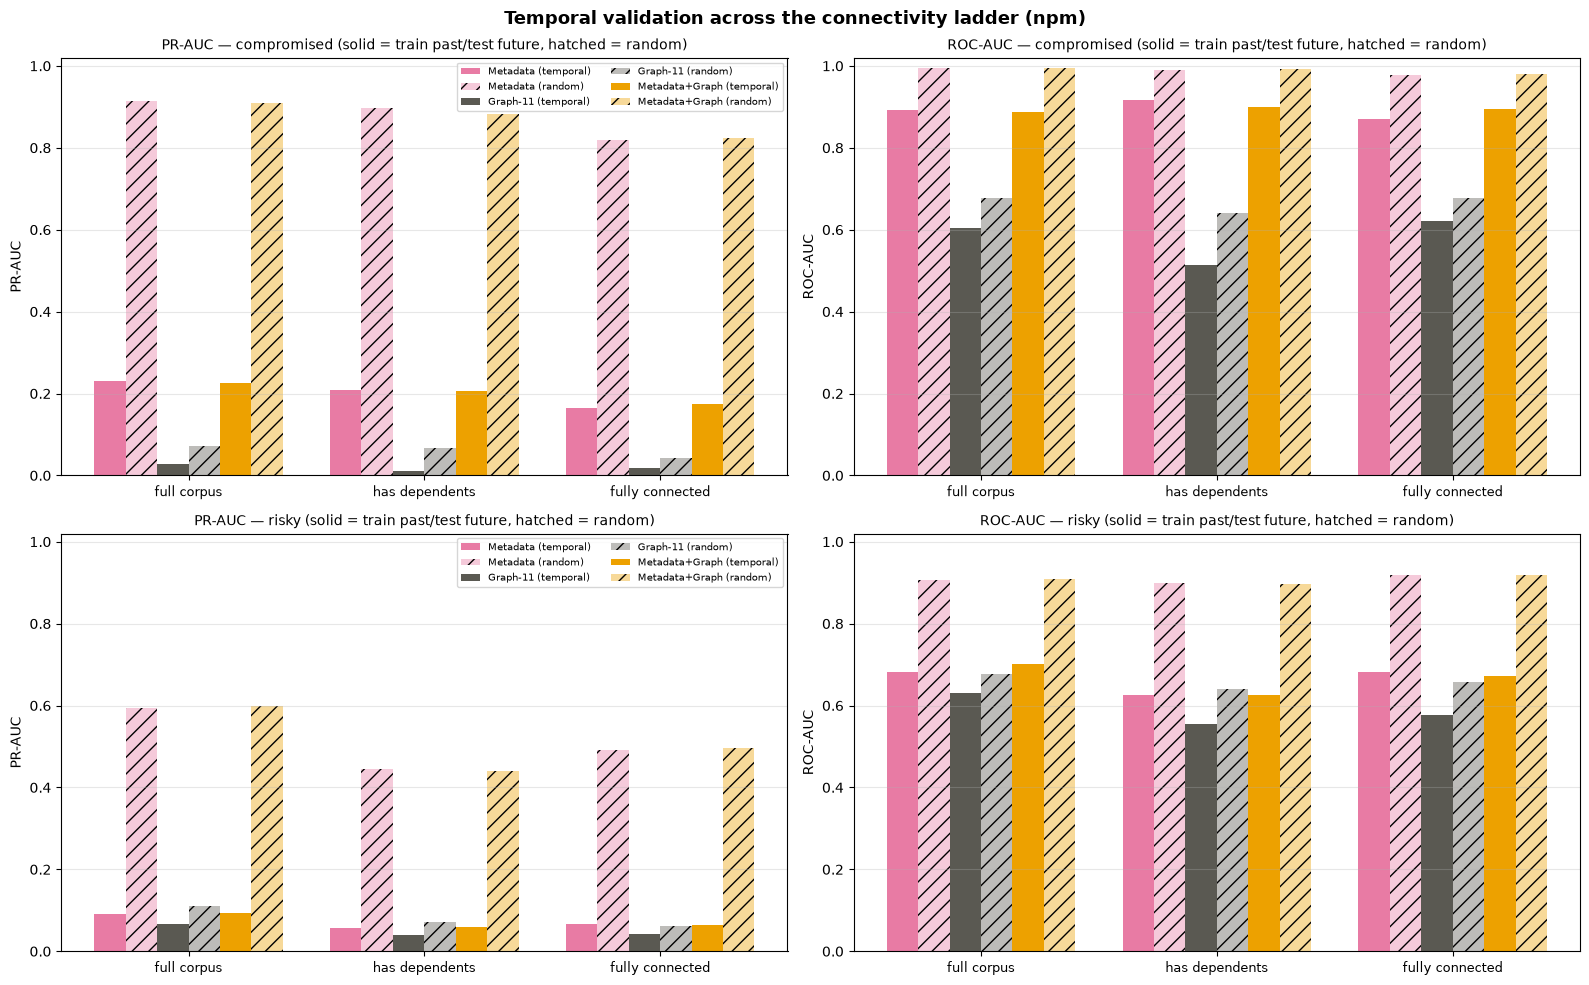

In [5]:
if len(temporal):
    for vname in temporal["view"].unique():
        sub = temporal[temporal.view == vname]
        print(f"\n{'='*100}\n{vname.upper()}\n{'='*100}")
        print(sub.set_index(["rung", "family"])[
            ["n_rows", "n_test_pos", "PR-AUC (temporal)", "PR-AUC (random)",
             "optimism gap (PR-AUC)", "ROC-AUC (temporal)", "ROC-AUC (random)"]]
            .to_string(float_format="{:.4f}".format))

    n_v = temporal["view"].nunique()
    fig, axes = plt.subplots(n_v, 2, figsize=(16, 5.0 * n_v), squeeze=False)
    for i, vname in enumerate(temporal["view"].unique()):
        sub = temporal[temporal.view == vname]
        rungs = [r for r in RUNGS if r in set(sub.rung)]
        fams = [f for f in FAM_COLOR if f in set(sub.family)]
        for ax, metric in zip(axes[i], ["PR-AUC", "ROC-AUC"]):
            x = np.arange(len(rungs)); w = 0.8 / max(len(fams) * 2, 1)
            for j, fam in enumerate(fams):
                t = [float(sub[(sub.rung == r) & (sub.family == fam)][f"{metric} (temporal)"].iloc[0])
                     for r in rungs]
                rr = [float(sub[(sub.rung == r) & (sub.family == fam)][f"{metric} (random)"].iloc[0])
                      for r in rungs]
                ax.bar(x + (2 * j - len(fams) + 0.5) * w, t, w, color=FAM_COLOR[fam],
                       label=f"{fam} (temporal)")
                ax.bar(x + (2 * j - len(fams) + 1.5) * w, rr, w, color=FAM_COLOR[fam],
                       alpha=0.40, hatch="//", label=f"{fam} (random)")
            ax.set_xticks(x); ax.set_xticklabels([r.split(": ")[1] for r in rungs], fontsize=9)
            ax.set_ylabel(metric); ax.set_ylim(0, 1.02); ax.grid(axis="y", alpha=0.3)
            ax.set_title(f"{metric} — {vname} (solid = train past/test future, hatched = random)",
                         fontsize=10)
        axes[i][0].legend(fontsize=7, loc="upper right", ncol=2)
    fig.suptitle(f"Temporal validation across the connectivity ladder ({ECO_TITLE})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "temporal_ladder.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)
else:
    print("No (view, rung) combination had enough timestamped positives on both sides "
          "of a cutoff — nothing to plot for this ecosystem.")

## 6. What carries the structural signal, per rung

Permutation importance (AUROC drop) of the canonical 11 on the future test set:
view                      compromised                                               risky                                     
rung                   A: full corpus B: has dependents C: fully connected A: full corpus B: has dependents C: fully connected
feature                                                                                                                       
closeness                      0.0443            0.0114             0.0699         0.0303            0.0263             0.0249
in_degree                      0.0415            0.0253             0.0083         0.0105           -0.0008            -0.0021
log1p_driving_power            0.0400            0.0059             0.0213         0.0118            0.0066            -0.0050
log1p_dependence_power         0.0331            0.0147             0.0175         0.0256            0.0042            -0.0057
pagerank                       

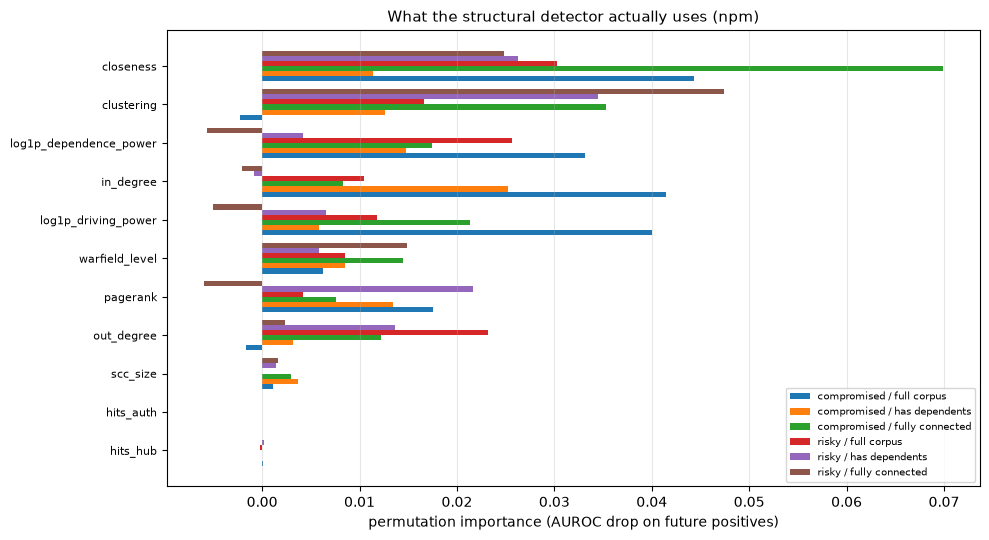

In [6]:
imp_rows = []
for (vname, rung), (mdl, Xf, te_i, yte) in PERM.items():
    if len(np.unique(yte)) < 2:
        continue
    sub_i = np.random.default_rng(SEED).choice(len(te_i), size=min(8000, len(te_i)), replace=False)
    pi = permutation_importance(mdl, Xf[te_i][sub_i], yte[sub_i], scoring="roc_auc",
                                n_repeats=6, random_state=SEED, n_jobs=N_JOBS)
    for f, m in zip(GRAPH_FEATURES, pi.importances_mean):
        imp_rows.append({"view": vname, "rung": rung, "feature": f, "importance": float(m)})
imp = pd.DataFrame(imp_rows)
if len(imp):
    imp.to_csv(OUT_DIR / "graph_importance.csv", index=False)
    piv = imp.pivot_table(index="feature", columns=["view", "rung"], values="importance")
    print("Permutation importance (AUROC drop) of the canonical 11 on the future test set:")
    print(piv.sort_values(piv.columns[0], ascending=False).to_string(float_format="{:.4f}".format))

    fig, ax = plt.subplots(figsize=(10, 5.5))
    order = piv.mean(axis=1).sort_values().index
    xb = np.arange(len(order)); ncol = len(piv.columns)
    for j, col in enumerate(piv.columns):
        ax.barh(xb + (j - (ncol - 1) / 2) * (0.8 / ncol), piv.loc[order, col],
                0.8 / ncol, label=f"{col[0]} / {col[1].split(': ')[1]}")
    ax.set_yticks(xb); ax.set_yticklabels(order, fontsize=8)
    ax.set_xlabel("permutation importance (AUROC drop on future positives)")
    ax.set_title(f"What the structural detector actually uses ({ECO_TITLE})", fontsize=11)
    ax.legend(fontsize=7); ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "graph_importance.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)
else:
    print("No rung produced a usable Graph-11 model for permutation importance.")

## 7. Summary

In [8]:
summary = {"ecosystem": ECO, "runtime_min": (time.time() - t_nb) / 60,
            "n_rung_A": int(RUNG_MASK["A: full corpus"].sum()),
            "n_rung_B": int(RUNG_MASK["B: has dependents"].sum()),
            "n_rung_C": int(RUNG_MASK["C: fully connected"].sum()),
            "n_evaluations": int(len(temporal))}
if len(temporal):
    for (vname, rung), g in temporal.groupby(["view", "rung"]):
        tag = f"{vname}_{rung.split(':')[0]}"
        best = g.sort_values("PR-AUC (temporal)", ascending=False).iloc[0]
        summary[f"{tag}_best_family"] = best["family"]
        summary[f"{tag}_best_prauc_temporal"] = round(float(best["PR-AUC (temporal)"]), 4)
        summary[f"{tag}_mean_optimism"] = round(float(g["optimism gap (PR-AUC)"].mean()), 4)
    summary["max_optimism_family"] = str(
        temporal.groupby("family")["optimism gap (PR-AUC)"].mean().idxmax())
    summary["min_optimism_family"] = str(
        temporal.groupby("family")["optimism gap (PR-AUC)"].mean().idxmin())
pd.Series(summary).to_frame("value").to_csv(OUT_DIR / "summary.csv")
print(pd.Series(summary).to_string())

ecosystem                                       npm
runtime_min                               12.319408
n_rung_A                                     101350
n_rung_B                                      49967
n_rung_C                                      35236
n_evaluations                                    18
compromised_A_best_family                  Metadata
compromised_A_best_prauc_temporal            0.2312
compromised_A_mean_optimism                  0.4705
compromised_B_best_family                  Metadata
compromised_B_best_prauc_temporal            0.2094
compromised_B_mean_optimism                  0.4736
compromised_C_best_family            Metadata+Graph
compromised_C_best_prauc_temporal            0.1751
compromised_C_mean_optimism                  0.4438
risky_A_best_family                  Metadata+Graph
risky_A_best_prauc_temporal                  0.0946
risky_A_mean_optimism                        0.3504
risky_B_best_family                  Metadata+Graph
risky_B_best